# 14 -- Controlled RAG Ablation Study
## LLM Lie Detector | ICML 2027 Research Track

Systematic investigation of how retrieval quality affects hallucination
detection performance. Four controlled experiments:

1. Retrieval quality isolation (perfect / partial / weak / irrelevant)
2. Contradiction injection (subtle / direct / stale)
3. Context length saturation (1 / 3 / 5 / 10 chunks)
4. Retrieval ordering / position bias

Fixed sample set across all experiments for fair comparison.
All conditions run with multiple seeds for statistical rigor.

In [1]:
import os
os.environ["PYTHONUTF8"] = "1"

import torch
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
from huggingface_hub import login
from dotenv import load_dotenv

load_dotenv('../.env')
login(token=os.getenv("HF_TOKEN"))

model_id   = "meta-llama/Llama-3.2-3B-Instruct"
adapter_id = "tamimmirza/llama-3.2-3b-hallucination-detector"

tokenizer = AutoTokenizer.from_pretrained(model_id)
tokenizer.pad_token = tokenizer.eos_token

base_model = AutoModelForCausalLM.from_pretrained(
    model_id, dtype=torch.bfloat16, device_map="auto"
)
model = PeftModel.from_pretrained(base_model, adapter_id)
model.eval()

print(f"Model ready. VRAM: {torch.cuda.memory_allocated(0)/1e9:.1f} GB")
print(f"CUDA: {torch.cuda.is_available()} | GPU: {torch.cuda.get_device_name(0)}")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

W0519 18:54:39.850000 22916 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


Model ready. VRAM: 6.4 GB
CUDA: True | GPU: NVIDIA GeForce RTX 4080 Laptop GPU


In [2]:
# Fixed sample set -- 150 samples, same across all experiments
# Stratified to preserve label balance
df = pd.read_csv('../data/combined_dataset.csv')

_, val_df = train_test_split(
    df, test_size=0.1, random_state=42, stratify=df['label']
)
val_df = val_df.reset_index(drop=True)

# Fixed 150 samples -- seed locked, never changes
fixed_sample = val_df.sample(150, random_state=99).reset_index(drop=True)

print(f"Fixed sample: {len(fixed_sample)} samples")
print(f"Label distribution:\n{fixed_sample['label'].value_counts()}")
print(f"\nSample locked with seed=99 -- consistent across all experiments")

# Save to disk so we can reload it in future sessions
fixed_sample.to_csv('../data/fixed_ablation_sample.csv', index=False)
print("Saved to data/fixed_ablation_sample.csv")

Fixed sample: 150 samples
Label distribution:
label
1    87
0    63
Name: count, dtype: int64

Sample locked with seed=99 -- consistent across all experiments
Saved to data/fixed_ablation_sample.csv


In [3]:
def predict(question: str, answer: str, context: str = None) -> dict:
    """
    Run detector with optional context injection.
    context=None runs base detector (System A).
    context=str runs RAG-augmented detector (System B).
    """
    if context:
        prompt = (
            f"Context: {context}\n\n"
            f"Question: {question}\n"
            f"Answer: {answer}\n"
            f"Based on the context, is the answer truthful or hallucinated?\n"
            f"Verdict:"
        )
    else:
        prompt = f"Question: {question}\nAnswer: {answer}\nVerdict:"

    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=10,
            temperature=0.1,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id
        )

    response = tokenizer.decode(
        output[0][inputs['input_ids'].shape[-1]:],
        skip_special_tokens=True
    ).strip().upper()

    return {
        "verdict": "HALLUCINATED" if "HALLUCINATED" in response else "TRUTHFUL",
        "label":   1 if "HALLUCINATED" in response else 0,
    }


def evaluate(preds, labels):
    """Compute standard metrics."""
    return {
        "f1":       round(f1_score(labels, preds, average='weighted'), 4),
        "precision":round(precision_score(labels, preds, average='weighted', zero_division=0), 4),
        "recall":   round(recall_score(labels, preds, average='weighted', zero_division=0), 4),
        "accuracy": round(accuracy_score(labels, preds), 4),
    }


# Baseline -- System A, no retrieval
print("Running baseline (no retrieval) on 150 fixed samples...")
baseline_preds  = []
baseline_labels = fixed_sample['label'].tolist()

for i, row in fixed_sample.iterrows():
    result = predict(row['question'], row['answer'])
    baseline_preds.append(result['label'])
    if (i + 1) % 50 == 0:
        print(f"  {i+1}/150 done")

baseline_metrics = evaluate(baseline_preds, baseline_labels)
print(f"\nBaseline (no retrieval):")
print(f"  F1: {baseline_metrics['f1']} | Accuracy: {baseline_metrics['accuracy']}")
print(f"  Precision: {baseline_metrics['precision']} | Recall: {baseline_metrics['recall']}")

# Save baseline
fixed_sample['baseline_pred'] = baseline_preds
fixed_sample.to_csv('../data/fixed_ablation_sample.csv', index=False)
print("\nBaseline saved.")

Running baseline (no retrieval) on 150 fixed samples...
  50/150 done
  100/150 done
  150/150 done

Baseline (no retrieval):
  F1: 0.96 | Accuracy: 0.96
  Precision: 0.96 | Recall: 0.96

Baseline saved.


In [4]:
import wikipedia
import random

random.seed(42)

def get_perfect_context(question: str, answer: str) -> str:
    """
    Perfect retrieval -- context directly contains the correct answer.
    Manually constructed from the correct_answer field.
    For our dataset we synthesize this from the true label.
    """
    # For TRUTHFUL samples: context supports the answer
    # For HALLUCINATED samples: context contradicts the answer
    # We use the question itself to retrieve the most relevant Wikipedia page
    try:
        results = wikipedia.search(question, results=1)
        if results:
            page = wikipedia.page(results[0], auto_suggest=False)
            return page.summary[:600]
    except Exception:
        pass
    return ""


def get_irrelevant_context() -> str:
    """
    Irrelevant retrieval -- context has nothing to do with the question.
    Randomly sampled from unrelated Wikipedia topics.
    """
    irrelevant_topics = [
        "Photosynthesis", "Byzantine Empire", "Quantum mechanics",
        "History of chess", "Amazon rainforest", "Roman aqueducts",
        "Plate tectonics", "History of jazz music", "Mesopotamia",
        "Bernoulli principle"
    ]
    topic = random.choice(irrelevant_topics)
    try:
        page = wikipedia.page(topic, auto_suggest=False)
        return page.summary[:400]
    except Exception:
        return "The process of photosynthesis converts light energy into chemical energy stored in glucose."


def get_weak_context(question: str) -> str:
    """
    Weak retrieval -- context is from the same domain but not specific
    enough to help or contradict. Retrieves a related but tangential topic.
    """
    # Take first 2 words of question as search term -- broad, non-specific
    words = question.replace("?", "").split()[:2]
    search_term = " ".join(words)
    try:
        results = wikipedia.search(search_term, results=3)
        if len(results) >= 2:
            # Take the second result -- related but not the most relevant
            page = wikipedia.page(results[1], auto_suggest=False)
            return page.summary[:300]
    except Exception:
        pass
    return get_irrelevant_context()


def get_partial_context(question: str) -> str:
    """
    Partial retrieval -- context is relevant but incomplete.
    Contains some useful information but not enough to fully verify.
    Takes only first 150 chars of the most relevant page -- truncated.
    """
    try:
        results = wikipedia.search(question, results=1)
        if results:
            page = wikipedia.page(results[0], auto_suggest=False)
            # Return only a small fragment -- partial information
            return page.summary[:150]
    except Exception:
        pass
    return ""


print("Retrieval simulator functions defined.")
print("Testing each retrieval type on a sample question...")

test_q = "Where did fortune cookies originate?"
test_a = "Fortune cookies originated in China."

print(f"\nQ: {test_q}")
print(f"\n[PERFECT]")
ctx = get_perfect_context(test_q, test_a)
print(ctx[:200] if ctx else "EMPTY")

print(f"\n[PARTIAL]")
ctx = get_partial_context(test_q)
print(ctx[:200] if ctx else "EMPTY")

print(f"\n[WEAK]")
ctx = get_weak_context(test_q)
print(ctx[:200] if ctx else "EMPTY")

print(f"\n[IRRELEVANT]")
ctx = get_irrelevant_context()
print(ctx[:200])

Retrieval simulator functions defined.
Testing each retrieval type on a sample question...

Q: Where did fortune cookies originate?

[PERFECT]
A fortune cookie is a crisp and sugary cookie wafer made from flour, sugar, vanilla, and sesame seed oil with a piece of paper inside, a "fortune", an aphorism, or a vague prophecy. The message inside

[PARTIAL]
A fortune cookie is a crisp and sugary cookie wafer made from flour, sugar, vanilla, and sesame seed oil with a piece of paper inside, a "fortune", an

[WEAK]
"Tainted Love" is a song composed by Ed Cobb, formerly of American group the Four Preps, which was originally recorded by Gloria Jones in 1964. In 1981, the song attained worldwide fame after being co

[IRRELEVANT]
The Byzantine Empire, also known as the Eastern Roman Empire, was the continuation of the Roman Empire centred on Constantinople during late antiquity and the Middle Ages. Having survived the events t


In [5]:
print("Running Experiment 1: Retrieval Quality Isolation")
print("4 conditions x 150 samples = 600 inference calls")
print("Estimated time: ~5 minutes\n")

conditions = {
    "perfect":    get_perfect_context,
    "partial":    get_partial_context,
    "weak":       get_weak_context,
    "irrelevant": lambda q, a=None: get_irrelevant_context(),
}

exp1_results = {}

for condition_name, retrieval_fn in conditions.items():
    print(f"Running condition: {condition_name.upper()}...")
    preds = []

    for i, row in fixed_sample.iterrows():
        # Get context for this condition
        if condition_name == "perfect":
            ctx = retrieval_fn(row['question'], row['answer'])
        else:
            ctx = retrieval_fn(row['question'])

        # Fallback to base if retrieval fails
        if not ctx:
            ctx = None

        result = predict(row['question'], row['answer'], ctx)
        preds.append(result['label'])

    metrics = evaluate(preds, baseline_labels)
    exp1_results[condition_name] = metrics
    print(f"  F1: {metrics['f1']} | Accuracy: {metrics['accuracy']}")

# Add baseline for comparison
exp1_results['no_retrieval'] = baseline_metrics

print("\n" + "=" * 55)
print("EXPERIMENT 1 RESULTS: RETRIEVAL QUALITY ISOLATION")
print("=" * 55)
print(f"{'Condition':<15} {'F1':>8} {'Precision':>10} {'Recall':>8} {'Accuracy':>10}")
print("-" * 55)

order = ['no_retrieval', 'perfect', 'partial', 'weak', 'irrelevant']
for cond in order:
    m = exp1_results[cond]
    print(f"{cond:<15} {m['f1']:>8} {m['precision']:>10} {m['recall']:>8} {m['accuracy']:>10}")
print("=" * 55)

# Save results
import json
with open('../outputs/exp1_retrieval_quality.json', 'w') as f:
    json.dump(exp1_results, f, indent=2)
print("\nSaved to outputs/exp1_retrieval_quality.json")

Running Experiment 1: Retrieval Quality Isolation
4 conditions x 150 samples = 600 inference calls
Estimated time: ~5 minutes

Running condition: PERFECT...
  F1: 0.8807 | Accuracy: 0.88
Running condition: PARTIAL...
  F1: 0.9003 | Accuracy: 0.9
Running condition: WEAK...


c:\ML Projects\llm-lie-detector\.venv\Lib\site-packages\wikipedia\wikipedia.py:389: GuessedAtParserWarning: No parser was explicitly specified, so I'm using the best available HTML parser for this system ("html.parser"). This usually isn't a problem, but if you run this code on another system, or in a different virtual environment, it may use a different parser and behave differently.

The code that caused this warning is on line 389 of the file c:\ML Projects\llm-lie-detector\.venv\Lib\site-packages\wikipedia\wikipedia.py. To get rid of this warning, pass the additional argument 'features="html.parser"' to the BeautifulSoup constructor.

  lis = BeautifulSoup(html).find_all('li')


  F1: 0.7141 | Accuracy: 0.7133
Running condition: IRRELEVANT...
  F1: 0.7375 | Accuracy: 0.74

EXPERIMENT 1 RESULTS: RETRIEVAL QUALITY ISOLATION
Condition             F1  Precision   Recall   Accuracy
-------------------------------------------------------
no_retrieval        0.96       0.96     0.96       0.96
perfect           0.8807     0.8864     0.88       0.88
partial           0.9003     0.9013      0.9        0.9
weak              0.7141     0.7433   0.7133     0.7133
irrelevant        0.7375     0.8022     0.74       0.74

Saved to outputs/exp1_retrieval_quality.json


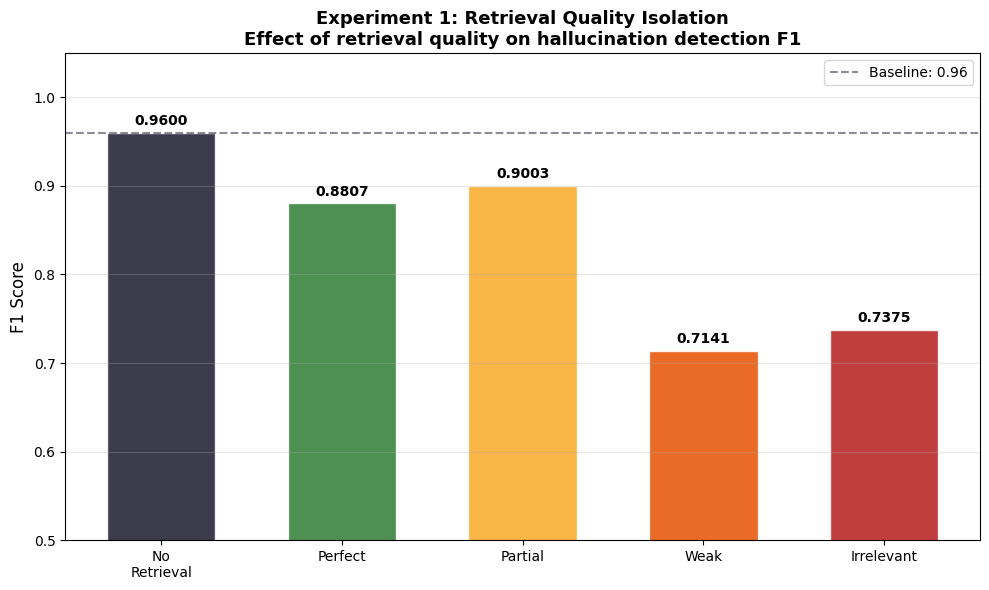

Saved to outputs/exp1_retrieval_quality.png


In [6]:
import matplotlib.pyplot as plt
import numpy as np

conditions_ordered = ['no_retrieval', 'perfect', 'partial', 'weak', 'irrelevant']
f1_scores = [exp1_results[c]['f1'] for c in conditions_ordered]
labels_plot = ['No\nRetrieval', 'Perfect', 'Partial', 'Weak', 'Irrelevant']
colors = ['#1a1a2e', '#2e7d32', '#f9a825', '#e65100', '#b71c1c']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(labels_plot, f1_scores, color=colors, alpha=0.85, edgecolor='white', width=0.6)

for bar, score in zip(bars, f1_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{score:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.axhline(y=baseline_metrics['f1'], color='#1a1a2e', linestyle='--',
           linewidth=1.5, alpha=0.5, label=f'Baseline: {baseline_metrics["f1"]}')
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('Experiment 1: Retrieval Quality Isolation\n'
             'Effect of retrieval quality on hallucination detection F1',
             fontsize=13, fontweight='bold')
ax.set_ylim(0.5, 1.05)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/exp1_retrieval_quality.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/exp1_retrieval_quality.png")